# Identify SGA 2020 Anchors within the SGA 2025

This was my attempt at matching the anchors into the SGA 2025 catalog when I first obtained the new cutout catalogs.
The majority of anchors were found, but there are still hundreds of anchors missing.

#### Research questions:
Are the SGA 2020 anchors usable for the SGA 2025?

In [1]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.table import Table, vstack

from SGA.SGA import get_galaxy_galaxydir, read_sga_sample
import h5py

In [2]:
OUTPUT_DIR = Path("/pscratch/sd/q/qshimp/Sorter")

OUTPUT_NAME = "sga2025"

N_GALAXIES = 1000

SEED = 67

PIXELS = 152

In [3]:
south, _ = read_sga_sample(region="dr11-south")
_, south_dirs = get_galaxy_galaxydir(south, region="dr11-south",)

north, _ = read_sga_sample(region="dr11-north")
_, north_dirs = get_galaxy_galaxydir(north, region="dr11-north",)

INFO:SGA.py:363:_read_catalog: Read 363,633/395,435 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-south.fits
INFO:SGA.py:370:_read_catalog: Selecting 363,633/363,633 objects in region=dr11-south
INFO:SGA.py:363:_read_catalog: Read 82,093/90,504 GROUP_PRIMARY objects from /dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-north.fits
INFO:SGA.py:370:_read_catalog: Selecting 82,093/82,093 objects in region=dr11-north


In [4]:
south_full = Table.read("/dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-south.fits", hdu=1)
north_full = Table.read("/dvs_ro/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/sample/SGA2025-beta-v1.6-dr11-north.fits", hdu=1)
full_catalog = vstack([south_full, north_full]).to_pandas()
full_catalog

,SGAID,SGAGROUP,REGION,OBJNAME,PGC,SAMPLE,ELLIPSEMODE,FITMODE,BX_INIT,BY_INIT,...,R26_Z,R26_ERR_G,R26_ERR_R,R26_ERR_I,R26_ERR_Z,D26,D26_ERR,D26_REF,BA,PA
0,1,b'SGA2025_00006m7218',1,b'ESO 050-IG 005 NED01',19,0,0,0,115.000000,115.000000,...,20.730068,0.190481,0.223729,0.183121,0.385860,0.592556,0.006441,b'r26',0.648238,166.152679
1,3,b'SGA2025_00011m0788',1,b'MCG -01-01-019',26,0,0,0,190.000000,190.000000,...,37.038269,0.624458,0.594346,0.669102,0.499232,1.144977,0.015968,b'r26',0.642450,135.010040
2,8,b'SGA2025_00034p1310',1,b'MCG +02-01-013',97,0,0,0,328.371307,556.269409,...,32.785458,0.441568,0.354047,0.611414,0.523861,0.848419,0.021999,b'z25',0.454454,125.113869
3,10,b'SGA2025_00040m8323',1,b'ESO 002- G 001',125,0,0,0,171.000000,171.000000,...,32.536701,0.201338,0.221995,0.228941,0.493924,0.951041,0.008583,b'r26',0.588619,79.648445
4,14,b'SGA2025_00070m6618',1,b'IC 5380',188,0,0,0,203.000000,203.000000,...,41.350044,0.125133,0.189694,0.287515,1.220454,1.219663,0.011042,b'r26',0.404209,131.705780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485934,5102161,b'SGA2025_16961p4531',2,b'PGC2262856',0,0,0,0,123.326942,123.197456,...,15.813060,0.131731,0.196511,0.000000,0.284278,0.626429,0.006298,b'r26',0.591223,163.113937
485935,5102162,b'SGA2025_20959p4768',2,b'PGC2302504',0,0,0,0,123.048187,123.018684,...,16.393415,0.137823,0.198570,0.000000,0.324019,0.675923,0.006588,b'r26',0.654966,10.949670
485936,5102163,b'SGA2025_22932p5726',2,b'PGC2561603',0,8,256,0,122.481087,120.813431,...,15.140684,0.192298,0.167277,0.000000,0.315018,0.490805,0.012930,b'z25',0.819405,69.742798
485937,5102164,b'SGA2025_17241p6096',2,b'PGC2609692',0,0,0,0,123.935631,124.028900,...,16.247696,0.089504,0.188066,0.000000,3.484871,0.620595,0.006210,b'r26',0.750345,4.526054


In [5]:
rows = []

for table, dirs in [(south, south_dirs), (north, north_dirs)]:
    for row, directory in zip(table, dirs):
        rows.append({
            "targetid": int(row["SGAID"]),
            "target_ra": float(row["RA"]),
            "target_dec": float(row["DEC"]),
            "g_mag": float(row["COG_MTOT_G"]),
            "r_mag": float(row["COG_MTOT_R"]),
            "z_mag": float(row["COG_MTOT_Z"]),
            "D26": float(row["D26"]),
            "Path": str(Path(directory)),
            "Main_Type": 30
        })

catalog = pd.DataFrame(rows)
catalog

,targetid,target_ra,target_dec,g_mag,r_mag,z_mag,D26,Path,Main_Type
0,1,0.066207,-72.186536,16.633167,15.731025,15.050040,0.592556,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
1,3,0.114649,-7.881941,15.730042,15.395398,15.235608,1.144977,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
2,10,0.408105,-83.236443,16.229027,15.550938,14.974306,0.951041,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
3,14,0.705979,-66.186566,14.629292,14.026855,13.572314,1.219663,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
4,19,0.930473,-83.410989,16.274879,15.736754,15.293338,0.834308,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
...,...,...,...,...,...,...,...,...,...
445721,5102161,169.618007,45.312700,16.343012,15.985199,16.087118,0.626429,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
445722,5102162,209.594914,47.684057,16.137659,15.507030,15.238227,0.675923,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
445723,5102163,229.329232,57.268293,16.730818,16.229519,16.299862,0.490805,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30
445724,5102164,172.415764,60.961845,16.372978,15.475228,15.095887,0.620595,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,30


In [6]:
random.seed(SEED)

sample = catalog.sample(
    n=N_GALAXIES,
    random_state=SEED,
).reset_index(drop=True)

In [7]:
outfile = OUTPUT_DIR / f"{OUTPUT_NAME}.csv"

catalog.to_csv(
    outfile,
    index=False,
)

print(outfile)

print(f"{len(catalog):,} galaxies saved.")

/pscratch/sd/q/qshimp/Sorter/sga2025.csv
445,726 galaxies saved.


In [8]:
sample["Path"][0]

'/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr11-south/228/22881p1783'

## Point Julia's anchors to SGA_2025 Catalog

In [9]:
galaxy_lookup = {}

for row, gdir in zip(south, south_dirs):
    galaxy_lookup[int(row["SGAID"])] = {
        "region": "dr11-south",
        "row": row,
        "galaxydir": gdir,
    }

for row, gdir in zip(north, north_dirs):
    galaxy_lookup[int(row["SGAID"])] = {
        "region": "dr11-north",
        "row": row,
        "galaxydir": gdir,
    }

anchor_sample = vstack([south, north])
galaxydirs = vstack([south_dirs, north_dirs])

# Fast lookup: SGAID -> row index in sample
sgaid_to_index = {
    int(sgaid): i
    for i, sgaid in enumerate(anchor_sample["SGAID"])
}

In [10]:
anchors = pd.read_csv("/pscratch/sd/q/qshimp/SGA2020-data/Anchors/VI_4000_sga152x152_complete.csv")
rows = []

for _, anchor in anchors.iterrows():

    sgaid = int(anchor["ref_id"])

    if sgaid not in galaxy_lookup:
        continue

    info = galaxy_lookup[sgaid]

    rows.append({
        "targetid": sgaid,
        "target_ra": info["row"]["RA"],
        "target_dec": info["row"]["DEC"],
        "g_mag": info["row"]["COG_MTOT_G"],
        "r_mag": info["row"]["COG_MTOT_R"],
        "z_mag": info["row"]["COG_MTOT_Z"],
        "Path": info["galaxydir"],      # <-- new directory
        "Main_Type": anchor["Main_type"],
    })

anchors_new = pd.DataFrame(rows)
anchors_new

,targetid,target_ra,target_dec,g_mag,r_mag,z_mag,Path,Main_Type
0,303570,317.094658,-19.967909,16.659672,16.125349,15.773440,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
1,22676,285.630939,-34.062796,17.111839,16.629173,16.225855,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
2,114179,102.162430,-52.864447,18.053572,17.140223,16.439264,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
3,303038,337.156434,-20.051426,17.116919,16.505466,15.940631,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
4,181930,75.652615,-42.228132,16.758020,15.492743,14.734072,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
...,...,...,...,...,...,...,...,...
113,125102,178.669664,-50.929299,17.112299,16.474159,16.020515,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
114,1000448,153.760049,13.778716,18.493279,17.931568,17.489326,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
115,72757,294.833730,-64.948316,17.255875,16.535761,15.934266,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
116,286493,185.779558,-22.606902,16.249023,15.738484,15.322181,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5


In [11]:
print(anchors["ref_id"].head(20).tolist())
print(sample["targetid"][:20])

[831151, 841964, 742784, 1007845, 396832, 390387, 1005162, 1114887, 218605, 198926, 562789, 1235151, 1287772, 731972, 175997, 1265391, 1115663, 464794, 1150415, 552163]
0     5031245
1     5048167
2     4894597
3     4947064
4     3150354
5     4728742
6     4906779
7     3864449
8     4899366
9     4912360
10    3141872
11    4856793
12    4689488
13    4767505
14    4769315
15    4474769
16    3205109
17    4808685
18    4994123
19    3450202
Name: targetid, dtype: int64


In [12]:
print("Anchor min/max:")
print(anchors["ref_id"].min(), anchors["ref_id"].max())

print("SGA2025 min/max:")
print(sample["targetid"].min(), sample["targetid"].max())

anchor_ids = set(anchors["ref_id"].astype(int))
sample_ids = set(sample["targetid"].astype(int))

print("Anchor IDs:", len(anchor_ids))
print("Sample IDs:", len(sample_ids))
print("Intersection:", len(anchor_ids & sample_ids))

Anchor min/max:
136 4008469
SGA2025 min/max:
13635 5102164
Anchor IDs: 4000
Sample IDs: 1000
Intersection: 1


In [13]:
intersection = set(anchors["ref_id"]).intersection(sample["targetid"])

print(intersection)

sgaid = next(iter(intersection))
print(sgaid)

{22676}
22676


In [14]:
anchor_row = anchors[anchors["ref_id"] == sgaid]
sample_row = sample[sample["targetid"] == sgaid]

print(anchor_row.T)
print(sample_row.T)

                                                          108
ref_id                                                  22676
ra                                                 142.937415
dec                                                 41.734174
g_mag                                               16.413786
z_mag                                               15.094078
r_mag                                               15.547629
Morphology                                               b'E'
T_type                                                   -5.0
Main_type                                                  20
Path        /pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...
                                                          493
targetid                                                22676
target_ra                                          285.630939
target_dec                                         -34.062796
g_mag                                               17.111839
r_mag   

In [15]:
print(type(sample))
print(type(sample["target_ra"]))
print(sample["target_ra"][:5])
print(getattr(sample["target_ra"], "unit", None))
print(getattr(sample["target_dec"], "unit", None))
print(type(sample["target_ra"].values))
print(sample["target_ra"].values.dtype)

print(type(anchors["ra"].values))
print(anchors["ra"].values.dtype)

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
0    228.818453
1    310.598299
2    160.336912
3    342.303227
4    338.249612
Name: target_ra, dtype: float64
None
None
<class 'numpy.ndarray'>
float64
<class 'numpy.ndarray'>
float64


In [16]:
from astropy.coordinates import SkyCoord
import astropy.units as u

SkyCoord(
    ra=float(full_catalog["RA"].iloc[0]) * u.deg,
    dec=float(full_catalog["DEC"].iloc[0]) * u.deg,
)

<SkyCoord (ICRS): (ra, dec) in deg
    (0.066207, -72.18653561)>

In [17]:
from astropy.coordinates import SkyCoord
import astropy.units as u

anchor_coords = SkyCoord(
    ra=anchors["ra"].to_numpy(dtype=float),
    dec=anchors["dec"].to_numpy(dtype=float),
    unit="deg",
)

sample_coords = SkyCoord(
    ra=full_catalog["RA"].to_numpy(dtype=float),
    dec=full_catalog["DEC"].to_numpy(dtype=float),
    unit="deg",
)

# Nearest-neighbor match
idx, sep2d, _ = anchor_coords.match_to_catalog_sky(sample_coords)

max_sep = 10 * u.arcsec

good = sep2d < max_sep

print(f"Matched {good.sum()} / {len(anchors)} anchors")

print("Minimum:", sep2d.min().arcsec, "arcsec")
print("Median :", np.median(sep2d.arcsec), "arcsec")
print("Maximum:", sep2d.max().arcsec, "arcsec")

Matched 3497 / 4000 anchors
Minimum: 0.00045401472350070524 arcsec
Median : 0.030581328675554614 arcsec
Maximum: 1608.427583162262 arcsec


<Angle [3.25722065e-02, 4.84788912e-07, 6.96877368e-06, ...,
        2.28085554e-05, 4.38791247e-05, 2.73026233e-05] deg>

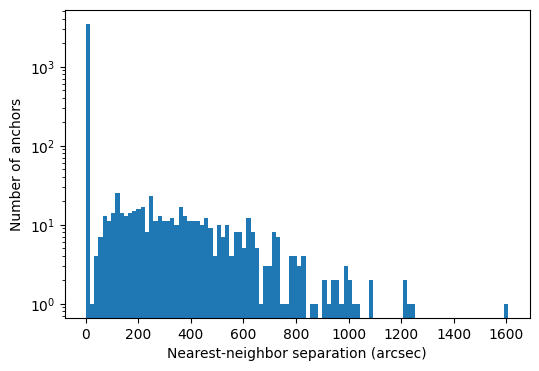

In [19]:
plt.figure(figsize=(6,4))
plt.hist(sep2d.arcsec, bins=100)
plt.xlabel("Nearest-neighbor separation (arcsec)")
plt.ylabel("Number of anchors")
plt.yscale("log")
plt.show()

In [20]:
matches = sep2d < max_sep

print("Matched:", matches.sum())
print("Unmatched:", (~matches).sum())

Matched: 3497
Unmatched: 503


Text(0, 0.5, 'Count')

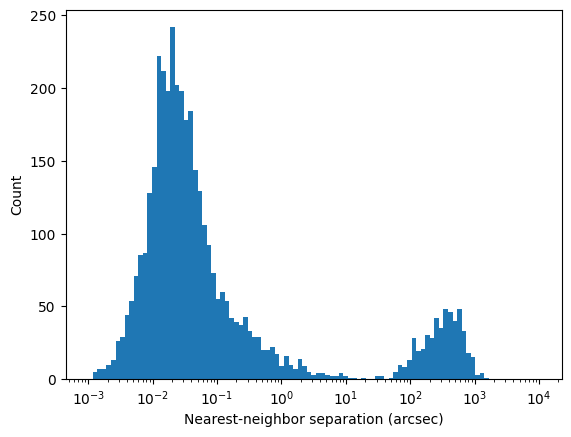

In [21]:
plt.hist(sep2d.arcsec, bins=np.logspace(-3, 4, 100))
plt.xscale("log")
plt.xlabel("Nearest-neighbor separation (arcsec)")
plt.ylabel("Count")

In [22]:
bad = np.where(~matches)[0]

for i in bad[:10]:
    print(anchors.iloc[i][["ref_id", "ra", "dec"]])
    print("nearest separation:", sep2d[i].arcsec)
    print()

ref_id        831151
ra        213.505901
dec        31.148203
Name: 0, dtype: object
nearest separation: 117.25994328389417

ref_id      1235151
ra        53.252419
dec      -35.451986
Name: 11, dtype: object
nearest separation: 165.5328047276836

ref_id       1222729
ra        229.187811
dec         7.055623
Name: 21, dtype: object
nearest separation: 107.70149106717616

ref_id         11154
ra        136.844892
dec        44.110803
Name: 27, dtype: object
nearest separation: 299.25144921768185

ref_id        814844
ra        207.196181
dec        36.474932
Name: 35, dtype: object
nearest separation: 152.17953911790295

ref_id        145218
ra        173.023381
dec         70.80653
Name: 40, dtype: object
nearest separation: 33.12123877900983

ref_id        996771
ra        179.831505
dec        65.020711
Name: 41, dtype: object
nearest separation: 318.97237475642623

ref_id        635841
ra        132.979235
dec        33.069801
Name: 47, dtype: object
nearest separation: 387.833769

In [23]:
bad_anchor_rows = anchors.iloc[bad]

bad_anchor_rows["dec"].describe()

count    503.000000
mean      26.390596
std       23.314028
min      -57.165937
25%        9.969412
50%       27.066474
75%       45.231116
max       79.085835
Name: dec, dtype: float64

Text(0, 0.5, 'Count')

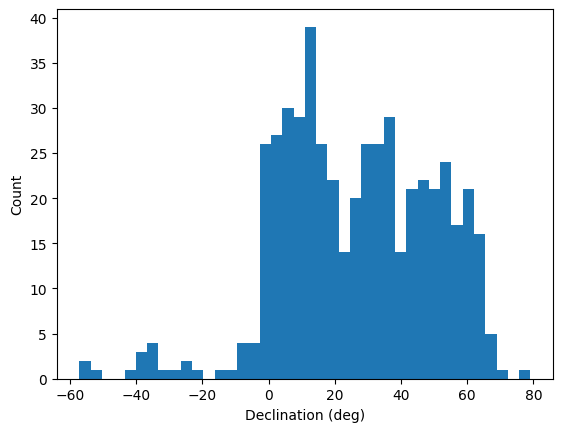

In [24]:
plt.hist(bad_anchor_rows["dec"], bins=40)
plt.xlabel("Declination (deg)")
plt.ylabel("Count")

In [25]:
dec = anchors.iloc[bad]["dec"].to_numpy(dtype=float)
bins = np.arange(-90, 91, 10)   # 10-degree bins

counts, edges = np.histogram(dec, bins=bins)

for left, right, count in zip(edges[:-1], edges[1:], counts):
    print(f"{left:>3.0f}° to {right:>3.0f}° : {count:4d}")

-90° to -80° :    0
-80° to -70° :    0
-70° to -60° :    0
-60° to -50° :    3
-50° to -40° :    1
-40° to -30° :    8
-30° to -20° :    4
-20° to -10° :    1
-10° to   0° :   29
  0° to  10° :   81
 10° to  20° :   91
 20° to  30° :   55
 30° to  40° :   76
 40° to  50° :   62
 50° to  60° :   54
 60° to  70° :   36
 70° to  80° :    2
 80° to  90° :    0


In [26]:
rows = []

for anchor_i, sample_i in zip(np.where(good)[0], idx[good]):

    anchor = anchors.iloc[anchor_i]
    galaxy = full_catalog.iloc[sample_i]

    rows.append({
        "targetid": int(galaxy["SGAID"]),          # SGA2025 ID
        "target_ra": float(galaxy["RA"]),
        "target_dec": float(galaxy["DEC"]),
        "g_mag": float(galaxy["COG_MTOT_G"]),
        "r_mag": float(galaxy["COG_MTOT_R"]),
        "z_mag": float(galaxy["COG_MTOT_Z"]),
        "Path": str(Path(directory)),                       # SGA2025 directory
        "Main_Type": int(anchor["Main_type"]),        # morphology from old anchors
    })

anchors_new = pd.DataFrame(rows)
anchors_new

,targetid,target_ra,target_dec,g_mag,r_mag,z_mag,Path,Main_Type
0,4897025,182.226241,60.719099,16.569122,15.715987,15.270308,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
1,4870942,144.671467,51.826075,14.922706,14.016303,13.656784,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
2,4940926,183.183562,31.450161,15.971468,15.092079,14.451480,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
3,4779748,200.345008,4.316778,16.712360,15.714384,15.080991,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
4,4777978,260.133428,28.100812,16.346996,15.448069,14.818049,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,20
...,...,...,...,...,...,...,...,...
3492,4917666,179.990945,49.564658,15.203836,14.608742,14.818854,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
3493,4955757,185.303180,8.963248,16.203535,15.513212,15.032456,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
3494,4734287,186.525151,31.859723,16.041611,15.468648,15.048287,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5
3495,5023725,163.462227,56.758521,16.931162,16.541454,16.557423,/dvs_ro/cfs/cdirs/cosmo/data/sga/2025/data/dr1...,-5


In [27]:


print("Original anchors")
print(
    anchors["Main_type"]
    .value_counts()
    .sort_index()
)

print("\nMatched anchors")
print(
    anchors_new["Main_Type"]
    .value_counts()
    .sort_index()
)

Original anchors
Main_type
-5     1000
 0     1000
 10    1000
 20    1000
Name: count, dtype: int64

Matched anchors
Main_Type
-5     924
 0     929
 10    795
 20    849
Name: count, dtype: int64


In [28]:
anchors_new.to_csv("/pscratch/sd/q/qshimp/SGA2025-data/julias_in_2025.csv", index=False)